In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import os
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(888)

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = 'data\\data_ori'
val_dir = 'data\\val'
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(val_dir), data_transforms['val'])
}
dataloaders = {x: DataLoader(
    image_datasets[x],
    batch_size=32,
    shuffle=(x=='train'),
    num_workers=8,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,             
) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

In [3]:
print(len(class_names))

10000


In [4]:
import torchvision.models as models
import torch.nn as nn
import torch
import torch.nn.functional as F
class SpatialTransformerNetwork(nn.Module):
    def __init__(self):
        super(SpatialTransformerNetwork, self).__init__()
        # Localization network - 用來預測變換參數
        self.localization = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=7),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d((1, 1))   # <- 降維，穩定並減少參數
        )

        # Fc 輸入從 10*52*52 -> 10
        self.fc_loc = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(True),
            nn.Linear(32, 3 * 2)  # 6 個參數用於仿射變換矩陣
        )

        # 初始化最後一層為恆等變換
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

    def forward(self, x):
        xs = self.localization(x)          # [B,10,1,1]
        xs = xs.view(-1, 10)              # [B,10]
        theta = self.fc_loc(xs)           # [B,6]
        theta = theta.view(-1, 2, 3)      # [B,2,3]

        # 執行空間變換，避免黑邊可用 padding_mode='border'
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        x = F.grid_sample(x, grid, align_corners=False, padding_mode='border')
        return x
    
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DepthwiseSeparableConv, self).__init__()
        
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.silu = nn.SiLU(inplace=True)
    
    def forward(self, x):
        x = self.silu(self.bn1(self.depthwise(x)))
        x = self.silu(self.bn2(self.pointwise(x)))
        return x
class FULL_block(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(FULL_block, self).__init__()
        self.conv = DepthwiseSeparableConv(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.silu = nn.SiLU(inplace=True)
        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride, bias=False)
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.conv(x)
        out += residual
        out = self.silu(out)
        return out
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.stn = SpatialTransformerNetwork()
        self.features = nn.Sequential(
            FULL_block(3, 16, kernel_size=3, stride=1, padding=1), #224
            FULL_block(16, 32, kernel_size=3, stride=1, padding=1), #112
            nn.AvgPool2d(kernel_size=2, stride=2),

            FULL_block(32, 64, kernel_size=3, stride=1, padding=1), #56
            nn.AvgPool2d(kernel_size=2, stride=2),

            FULL_block(64, 128, kernel_size=3, stride=1, padding=1), #28
            nn.AvgPool2d(kernel_size=2, stride=2),

            FULL_block(128, 192, kernel_size=3, stride=1, padding=1), #14   
            nn.AvgPool2d(kernel_size=2, stride=2),

            FULL_block(192, 256, kernel_size=3, stride=1, padding=1), #7

            nn.AdaptiveAvgPool2d((1, 1)) 
        )
    def forward(self, x):
        if self.training:
            x = self.stn(x)
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x


class CustomCNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNNModel, self).__init__()
        self.features = SimpleCNN()
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 宣告模型
model = CustomCNNModel(len(class_names))

# 印出模型架構
print(model)

CustomCNNModel(
  (features): SimpleCNN(
    (stn): SpatialTransformerNetwork(
      (localization): Sequential(
        (0): Conv2d(3, 8, kernel_size=(7, 7), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
        (3): Conv2d(8, 10, kernel_size=(5, 5), stride=(1, 1))
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (5): ReLU(inplace=True)
        (6): AdaptiveAvgPool2d(output_size=(1, 1))
      )
      (fc_loc): Sequential(
        (0): Linear(in_features=10, out_features=32, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=32, out_features=6, bias=True)
      )
    )
    (features): Sequential(
      (0): FULL_block(
        (conv): DepthwiseSeparableConv(
          (depthwise): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=3, bias=False)
          (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=

First, let's print the model architecture to understand its structure:

Run the above code to see the structure of the model. Look for the final layer that produces the class scores, typically named something like classifier, head, or fc.


From the model architecture, it looks like the final classification layer is named classifier. 

To modify this layer for your custom classification task, you should replace the classifier layer with a new Linear layer that has the appropriate number of output classes for your dataset.

In [5]:
# Move the model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [6]:
import torch.optim as optim

# Define loss function
criterion = torch.nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.00153, weight_decay=1e-4)

# # 載入預訓練模型（如果存在）
# pretrained_path = 'custom_eff28.pth'
# if os.path.exists(pretrained_path):
#     print(f"載入預訓練模型: {pretrained_path}")
#     model.load_state_dict(torch.load(pretrained_path, map_location=device))
#     print("模型載入成功，準備繼續訓練...")
# else:
#     print("未找到預訓練模型，將從頭開始訓練...")

# # 確保模型在正確的設備上
# model = model.to(device)

In [7]:
import time
import copy
from torch.optim.lr_scheduler import CosineAnnealingLR

report_train_acc = []
report_val_acc = []
report_train_loss = []
report_val_loss = []
num_epochs = 50

# 添加學習率調度器
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

def train_model(model, criterion, optimizer, scheduler, num_epochs):  # 新增scheduler參數
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print(f'Current Learning Rate: {scheduler.get_last_lr()[0]:.6f}')  # 顯示當前學習率
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'train':
                report_train_acc.append(epoch_acc)
                report_train_loss.append(epoch_loss)
            else:
                report_val_acc.append(epoch_acc)
                report_val_loss.append(epoch_loss)
            
            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        # 在每個epoch結束後調用scheduler.step()
        scheduler.step()
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Train the model (記得傳入scheduler參數)
model = train_model(model, criterion, optimizer, scheduler, num_epochs)

# Save the model
torch.save(model.state_dict(), 'final_no_flip.pth')

Epoch 0/49
Current Learning Rate: 0.001530
----------
train Loss: 9.1445 Acc: 0.0000
val Loss: 9.3405 Acc: 0.0001

Epoch 1/49
Current Learning Rate: 0.001528
----------
train Loss: 9.2368 Acc: 0.0000
val Loss: 9.2186 Acc: 0.0003

Epoch 2/49
Current Learning Rate: 0.001524
----------
train Loss: 9.1442 Acc: 0.0000
val Loss: 9.0182 Acc: 0.0006

Epoch 3/49
Current Learning Rate: 0.001516
----------
train Loss: 8.8970 Acc: 0.0000
val Loss: 8.6943 Acc: 0.0012

Epoch 4/49
Current Learning Rate: 0.001506
----------
train Loss: 8.5577 Acc: 0.0000
val Loss: 8.4888 Acc: 0.0022

Epoch 5/49
Current Learning Rate: 0.001493
----------
train Loss: 8.1629 Acc: 0.0000
val Loss: 8.2127 Acc: 0.0009

Epoch 6/49
Current Learning Rate: 0.001476
----------
train Loss: 7.7881 Acc: 0.0001
val Loss: 8.0388 Acc: 0.0020

Epoch 7/49
Current Learning Rate: 0.001457
----------
train Loss: 7.4919 Acc: 0.0001
val Loss: 7.8408 Acc: 0.0020

Epoch 8/49
Current Learning Rate: 0.001435
----------
train Loss: 7.2058 Acc: 0.

# Testing

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import time
from tqdm import tqdm

num_runs = 5
all_accuracies = []
all_errors = []

for run in range(num_runs):
    print(f"\n===== 第 {run+1} 次測試 =====")
    # 初始化模型架構
    model = CustomCNNModel(len(class_names))
    model_path = "final_no_flip.pth"
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(-360, 360)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    test_dataset = datasets.ImageFolder('data\\val', test_transform)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

    num_classes = len(test_dataset.classes)
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    class_predictions = [0] * num_classes
    total_correct = 0
    total_samples = 0
    avg_error = 0.0
    start_time = time.time()

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="測試進度"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)
            correct = (predictions == labels).sum().item()
            total_correct += correct
            total_samples += labels.size(0)
            for i in range(len(labels)):
                label = labels[i].item()
                prediction = predictions[i].item()
                class_total[label] += 1
                if label == prediction:
                    class_correct[label] += 1
                avg_error += ((abs(label // 100 - prediction // 100) ** 2 + abs(label % 100 - prediction % 100) ** 2) ** 0.5)
                class_predictions[prediction] += 1

    test_time = time.time() - start_time
    overall_accuracy = 100 * total_correct / total_samples
    mean_error = avg_error / total_samples
    all_accuracies.append(overall_accuracy)
    all_errors.append(mean_error)
    print(f'總體準確率: {overall_accuracy:.2f}% ({total_correct}/{total_samples})')
    print(f'測試完成，耗時: {test_time:.2f} 秒')
    print(f'平均誤差: {mean_error:.4f}')

print("\n===== 5 次測試結果彙總 =====")
print("準確率：", all_accuracies)
print("平均誤差：", all_errors)
print(f"平均準確率: {sum(all_accuracies)/num_runs:.2f}%")
print(f"平均誤差: {sum(all_errors)/num_runs:.4f}")


===== 第 1 次測試 =====


測試進度: 100%|██████████| 157/157 [00:13<00:00, 11.36it/s]


總體準確率: 0.13% (13/10000)
測試完成，耗時: 13.83 秒
平均誤差: 19.8188

===== 第 2 次測試 =====


測試進度: 100%|██████████| 157/157 [00:13<00:00, 11.75it/s]


總體準確率: 0.20% (20/10000)
測試完成，耗時: 13.36 秒
平均誤差: 19.7312

===== 第 3 次測試 =====


...

總體準確率: 0.16% (16/10000)
測試完成，耗時: 12.79 秒
平均誤差: 19.7080

===== 第 4 次測試 =====


測試進度: 100%|██████████| 157/157 [00:13<00:00, 11.76it/s]


總體準確率: 0.12% (12/10000)
測試完成，耗時: 13.35 秒
平均誤差: 19.9056

===== 第 5 次測試 =====


測試進度: 100%|██████████| 157/157 [00:13<00:00, 11.53it/s]

總體準確率: 0.16% (16/10000)
測試完成，耗時: 13.62 秒
平均誤差: 19.8747

===== 5 次測試結果彙總 =====
準確率： [0.13, 0.2, 0.16, 0.12, 0.16]
平均誤差： [19.8187690140494, 19.73115895176847, 19.707999688563902, 19.90561962196502, 19.874734343861153]
平均準確率: 0.15%
平均誤差: 19.8077


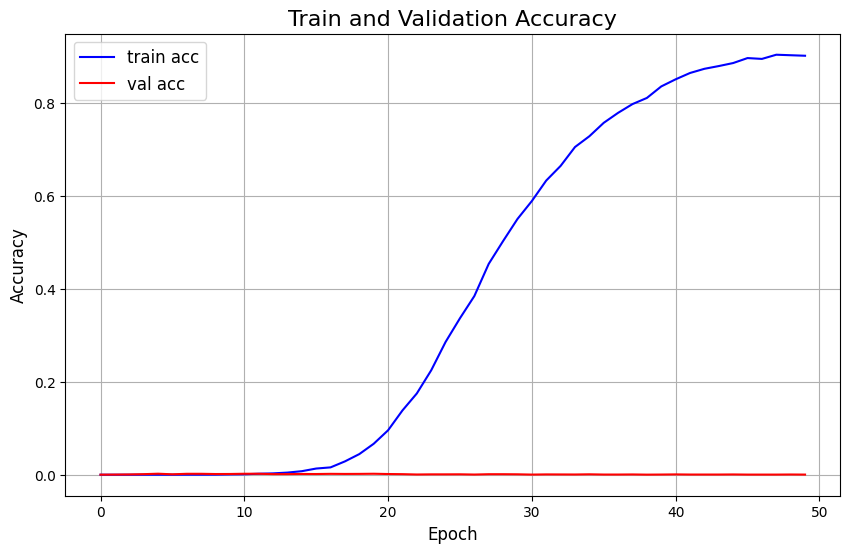

In [9]:
import matplotlib.pyplot as plt
import numpy as np

train_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in report_train_acc])
val_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in report_val_acc])
epochs = list(range(len(train_acc)))

plt.figure(figsize=(10,6))
plt.plot(epochs, train_acc, 'b-', label='train acc')
plt.plot(epochs, val_acc, 'r-', label='val acc')
plt.title('Train and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()